<a href="https://colab.research.google.com/github/paulinamena/Integracion-de-datos-y-prospectiva/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Integración de Datos – Entidad Prestadora de Salud**
Una entidad prestadora de salud quiere mejorar la eficiencia en la prestación de sus servicios de salud, para lo cual quiere cerrar una de sus sucursales.

De acuerdo con los objetivos descritos anteriormente, la entidad prestadora de salud quiere llevar a cabo el siguiente procedimiento, tomando como referencia una de las variables que caracterizan a los pacientes con Diabetes:

- La entidad prestadora de salud quiere saber cual es la sucursal de atención que tiene una mayor afinidad con la sucursal que se quiere cerrar (Sabaneta).
- Para determinar esta afinidad, la entidad prestadora de salud quiere llevar a cabo la estimación de la credibilidad entre la sucursal a cerrar y las demás sucursales utilizando la variable de referencia seleccionada.
- Para reubicar a sus pacientes, la entidad prestadora de salud quiere clasificar sus pacientes en las otras sucursales mediante el método del valor de pertenencia.
- Debido a que la entidad en salud tiene dudas frente al método de credibilidad y de integración por valor de pertenencia, la entidad prestadora de salud quiere hacer el mismo procedimiento de integración de pacientes mediante la utilización del método de aceptación y rechazo.
- Es importante para antes y después de la integración de los datos, llevar a cabo el análisis de las medidas de tendencia central y dispersión para cada una de las bases de datos, para antes y después de la integración de los nuevos pacientes.


- Teoría de la Credibilidad: Es un método que permite determinar la afinidad entre bases de datos de acuerdo con sus medidas de tendencia central y dispersión.
- Métodos de Aceptación y Rechazo: Agrupa una serie de métodos para la integración de datos basada en la estructura intrínseca de las variables de referencia utilizadas para la integración (Valor de Pertenencia, Aceptación/Rechazo).

Archivo: Parcial - medical_attention_data.xlsx


##**0. Se procede con la carga de las librerias de trabajo**


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

nxl='/content/drive/MyDrive/Integración de datos/Parcial 1/3. Parcial - medical_attention_data.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# @title Caracterización de Distribuciones de Probabilidad
def caracterizacion(LDA):

  #Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA,bins=10,kde=True)
  plt.xlabel("Pérdida (KUSD)")
  plt.grid()
  plt.show()

  #Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI=10    #Indica el número de clusters
  counts,bin_edges=np.histogram(LDA,bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC=(bin_edges[:-1]+bin_edges[1:])/2

  #Se configura la tabla de los datos
  Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
  df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
  df.head(10)

  #Se procede con la estimación de la media
  fr=counts/np.sum(counts)
  u=np.sum(XC*fr)
  sigma2=np.sum(fr*(XC-u)**2)
  sigma=np.sqrt(sigma2)
  Cas=np.sum(fr*(XC-u)**3)/sigma**3
  Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3

  return u,sigma,Cas,Kur,df

In [3]:
# @title Parametros de Riesgo
def RiskParameters(LDA):

  NDT=len(LDA)
  PE=np.mean(LDA)                        #Pérdidas Esperadas
  NPE=np.sum(LDA<PE)                     #Cuantos eventos de riesgo no generan cobro - Evergreen
  OpVar=np.percentile(LDAo,99.9)         #Valor Seguro para cubrir pérdidas catastróficas que requieren intervención de seguro
  NPC=np.sum(LDA>OpVar)                  #Pérdidas Catastróficas
  NPNE=NDT-NPE-NPC                       #Las pérdidas no esperadas - gestionables (llevo el carro al taller)

  return OpVar,NPE,NPNE,NPC

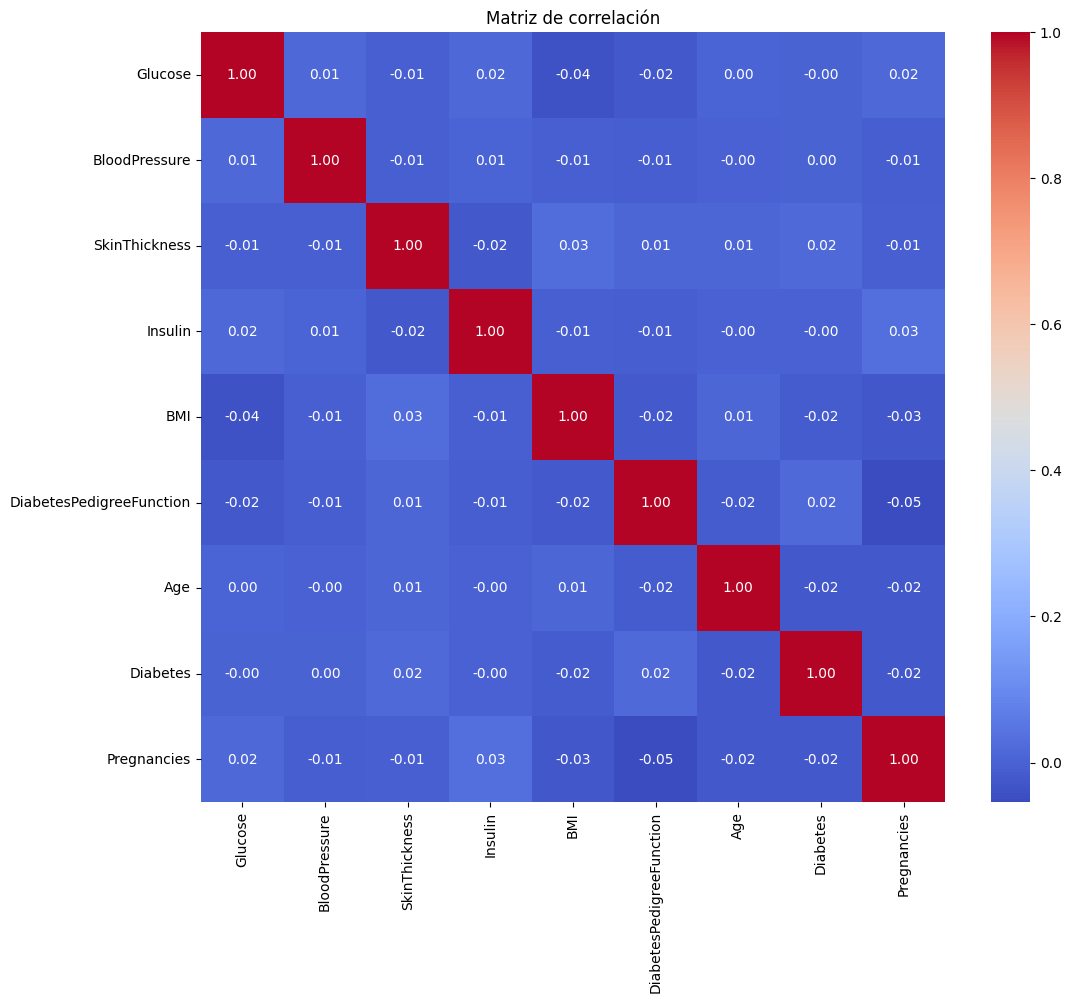

Correlación


,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Pregnancies
Glucose,1.000000,0.013956,-0.006072,0.015633,-0.039272,-0.021183,0.004046,-0.000049,0.015691
BloodPressure,0.013956,1.000000,-0.007808,0.005684,-0.008646,-0.011843,-0.003388,0.001454,-0.009923
SkinThickness,-0.006072,-0.007808,1.000000,-0.021895,0.025596,0.011530,0.007822,0.017592,-0.005091
Insulin,0.015633,0.005684,-0.021895,1.000000,-0.008352,-0.009968,-0.001410,-0.001180,0.029169
BMI,-0.039272,-0.008646,0.025596,-0.008352,1.000000,-0.018211,0.011701,-0.016266,-0.028170
DiabetesPedigreeFunction,-0.021183,-0.011843,0.011530,-0.009968,-0.018211,1.000000,-0.015497,0.016801,-0.054097
Age,0.004046,-0.003388,0.007822,-0.001410,0.011701,-0.015497,1.000000,-0.023539,-0.021736
Diabetes,-0.000049,0.001454,0.017592,-0.001180,-0.016266,0.016801,-0.023539,1.000000,-0.024751
Pregnancies,0.015691,-0.009923,-0.005091,0.029169,-0.028170,-0.054097,-0.021736,-0.024751,1.000000


In [68]:
# @title Correlación
# Get all sheet names from the Excel file
xcel_file = pd.ExcelFile(nxl)
sheet_names = xcel_file.sheet_names

# Initialize an empty list to store DataFrames
all_dfs = []

# Read each sheet into a DataFrame and append to the list
for sheet_name in sheet_names:
    df = pd.read_excel(nxl, sheet_name=sheet_name)
    all_dfs.append(df)

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

# Identify numerical columns for correlation
numerical_cols = combined_df.select_dtypes(include=['number']).columns

# Calculate the correlation matrix
correlation_matrix = combined_df[numerical_cols].corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()

print("Correlación")
display(correlation_matrix)

Dada la matriz de correlación se tomo la desición de hacer uso de la variable BMI

##**1. Se procede con la carga de los archivos de trabajo**

In [107]:

# @title Función de Credibilidad

def Credibilidad(LDAo,LDAex):
  #Se procede del valor esperado de la varianza
  uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
  uex,sigmaex,Casex,Kurex,dfex=caracterizacion(LDAex)
  NDo=len(LDAo);NDex=len(LDAex)
  EPV=(sigmao*NDo+sigmaex*NDex)/(NDo+NDex)

  #Se procede con la estimación del Valor Hipotetico de la Media
  uh=(uo*NDo+uex*NDex)/(NDo+NDex)
  VHM=((NDo*uo**2+NDex*uex**2)/(NDo+NDex))-uh**2

  #Se procede con la estimación del fc
  fc=EPV/VHM

  #Se procede con la estimación de la credibilidad
  Cr=NDo/(NDo+fc)
  print("La media de los datos internos es:",uo)
  print("La media de los datos externos es:",uex)
  print("La credibilidad es:",Cr)

  return Cr

###Bello

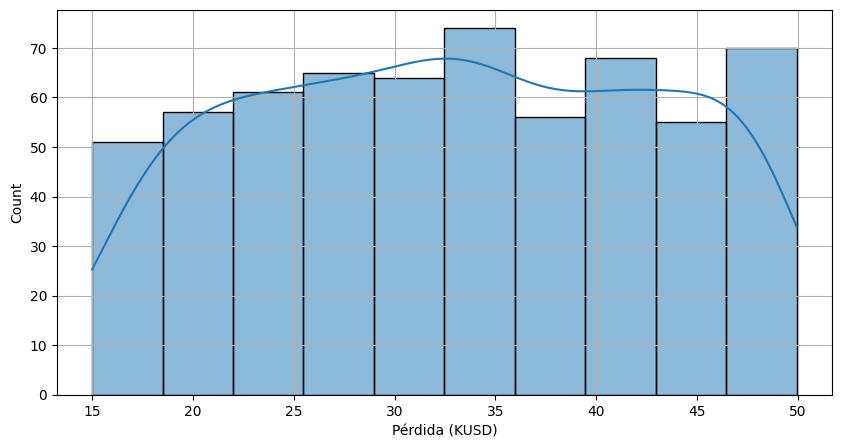

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


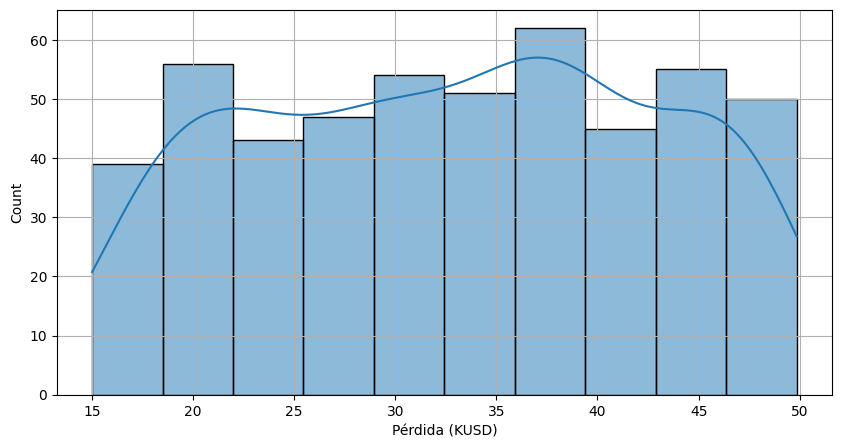

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]


In [108]:


#Se procede con la caracterización de la distribución de datos internos
XDBo=pd.read_excel(nxl,sheet_name=4) # Commented out the original line causing the error
LDAo=XDBo.iloc[:,5]
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
OpVaro,NPEo,NPNEo,NPCo=RiskParameters(LDAo)

#Se procede con la caracterización de la distribución de los datos externos - bello
XDBb=pd.read_excel(nxl,sheet_name=0) # Commented out the original line causing the error
LDAb=XDBb.iloc[:,5]
ub,sigmab,Casb,Kurb,dfb=caracterizacion(LDAb)
OpVarb,NPEb,NPNEb,NPCb=RiskParameters(LDAb)

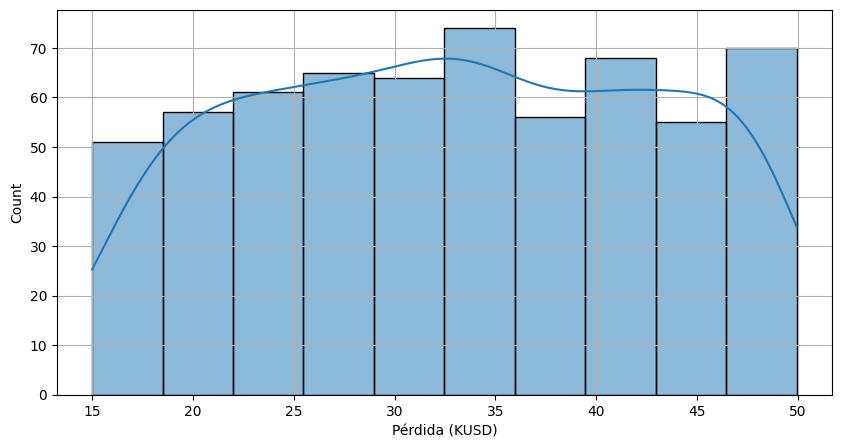

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


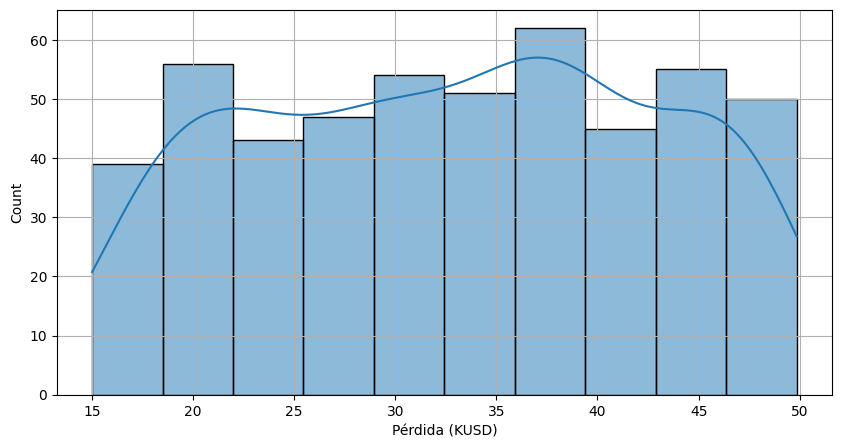

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La credibilidad es: 0.022050146729361828


np.float64(0.022050146729361828)

In [109]:
#Se procede del valor esperado de la varianza
Credibilidad(LDAo,LDAb)

###Medellín

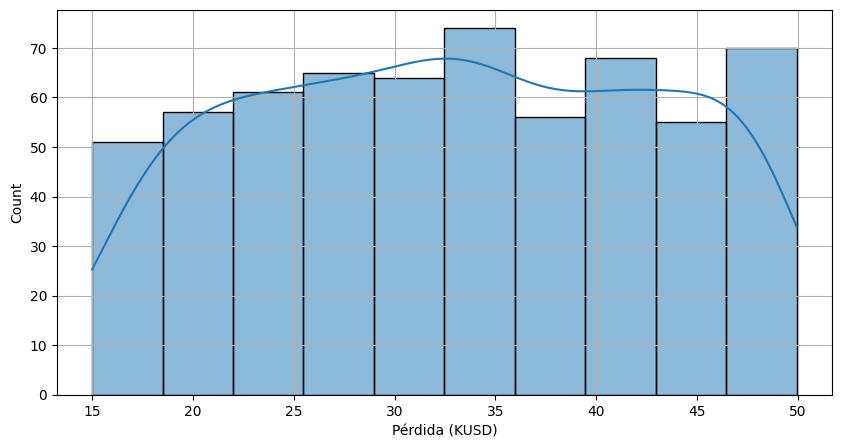

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


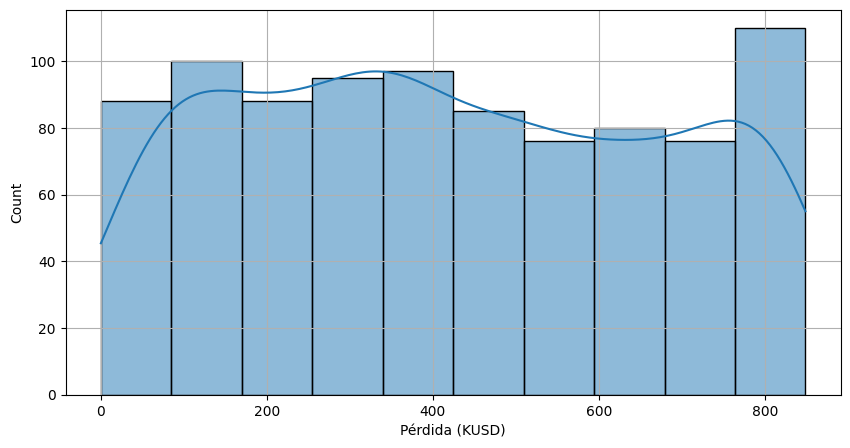

El número de datos por intervalo es:
[ 88 100  88  95  97  85  76  80  76 110]
Los intervalos inferiores:
[  0.   84.9 169.8 254.7 339.6 424.5 509.4 594.3 679.2 764.1]
Los intervalos superiores:
[ 84.9 169.8 254.7 339.6 424.5 509.4 594.3 679.2 764.1 849. ]


In [110]:
#Se procede con la caracterización de la distribución de datos internos - sabaneta
XDBo=pd.read_excel(nxl,sheet_name=4) # Commented out the original line causing the error
LDAo=XDBo.iloc[:,5]
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
OpVaro,NPEo,NPNEo,NPCo=RiskParameters(LDAo)

#Se procede con la caracterización de la distribución de los datos externos - Medellin
XDBm=pd.read_excel(nxl,sheet_name=1) # Commented out the original line causing the error
LDAm=XDBm.iloc[:,5]
um,sigmam,Casm,Kurm,dfm=caracterizacion(LDAm)
OpVarm,NPEm,NPNEm,NPCm=RiskParameters(LDAm)

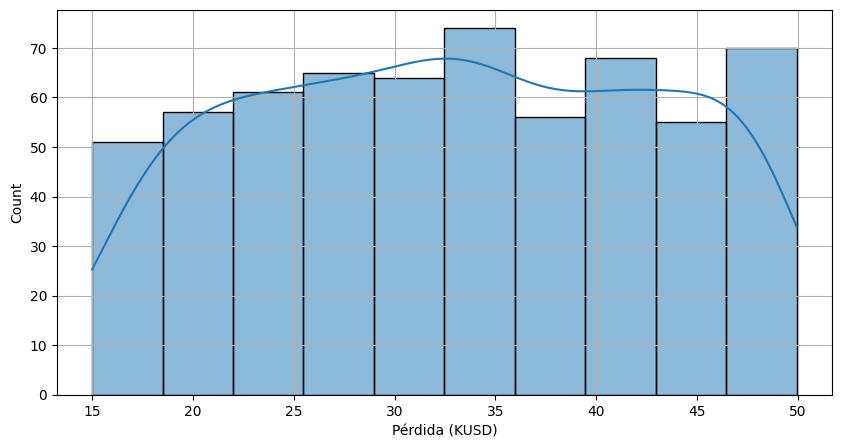

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


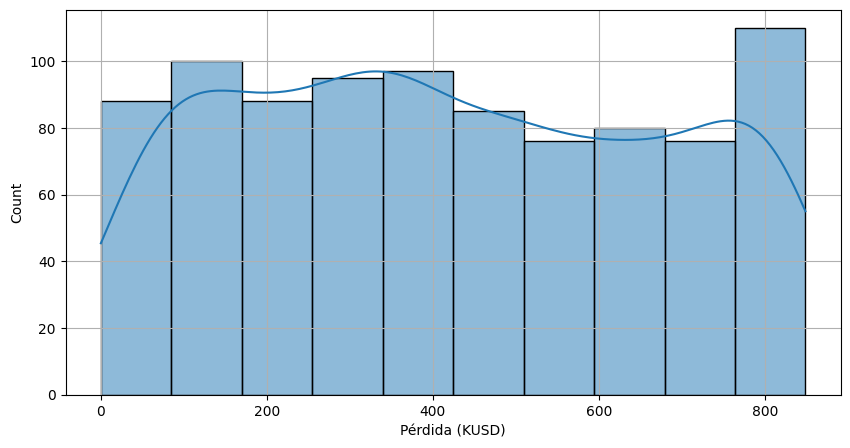

El número de datos por intervalo es:
[ 88 100  88  95  97  85  76  80  76 110]
Los intervalos inferiores:
[  0.   84.9 169.8 254.7 339.6 424.5 509.4 594.3 679.2 764.1]
Los intervalos superiores:
[ 84.9 169.8 254.7 339.6 424.5 509.4 594.3 679.2 764.1 849. ]
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 420.75301675977653
La credibilidad es: 0.9999933354698058


In [111]:
#Se procede del valor esperado de la varianza
Crm=Credibilidad(LDAo,LDAm)

###Envigado

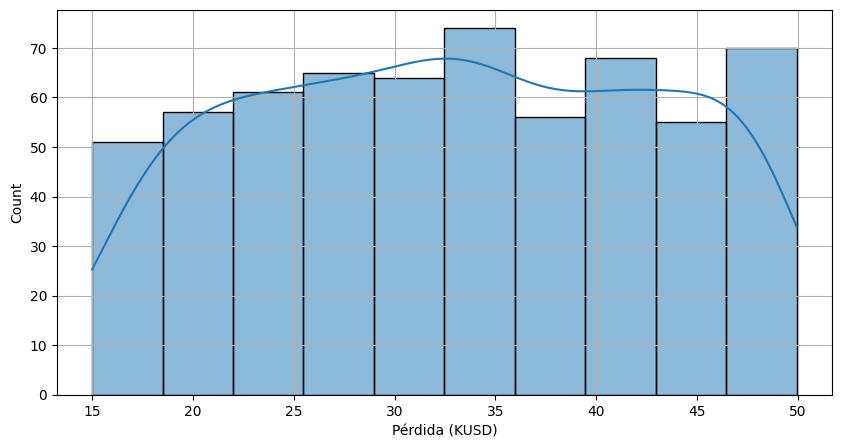

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


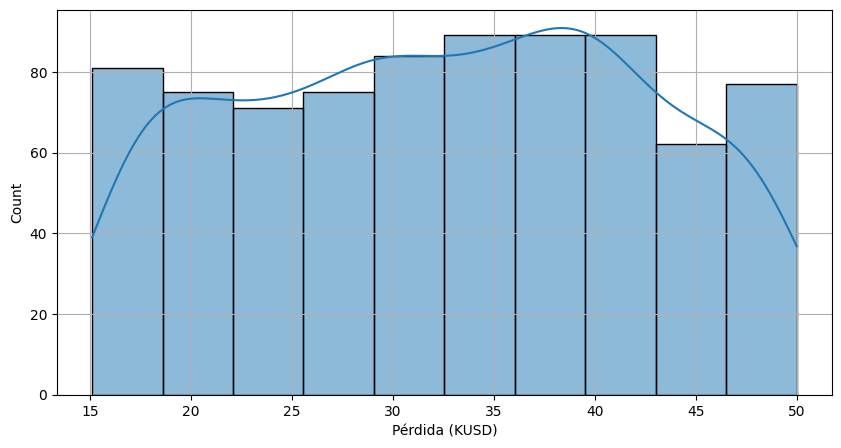

El número de datos por intervalo es:
[81 75 71 75 84 89 89 89 62 77]
Los intervalos inferiores:
[15.096  18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136
 46.5033]
Los intervalos superiores:
[18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136 46.5033
 49.993 ]


In [112]:
#Se procede con la caracterización de la distribución de datos internos
XDBo=pd.read_excel(nxl,sheet_name=4) # Commented out the original line causing the error
LDAo=XDBo.iloc[:,5]
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
OpVaro,NPEo,NPNEo,NPCo=RiskParameters(LDAo)

#Se procede con la caracterización de la distribución de los datos externos - bello
XDBe=pd.read_excel(nxl,sheet_name=2) # Commented out the original line causing the error
LDAe=XDBe.iloc[:,5]
ue,sigmae,Case,Kure,dfe=caracterizacion(LDAe)
OpVare,NPEe,NPNEe,NPCe=RiskParameters(LDAe)

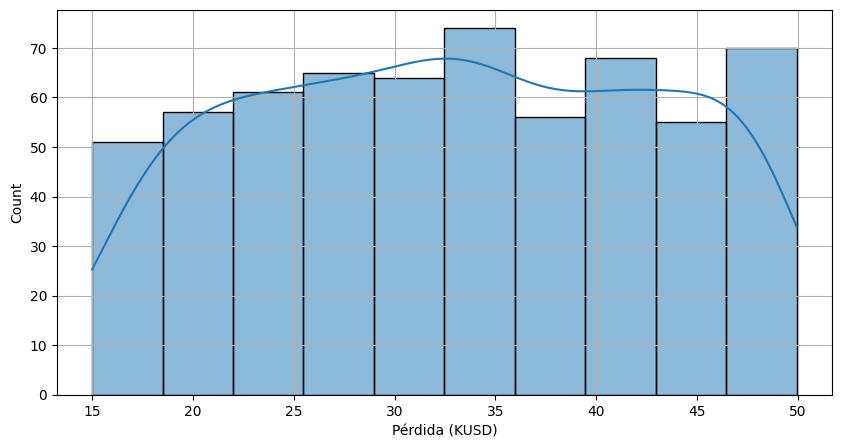

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


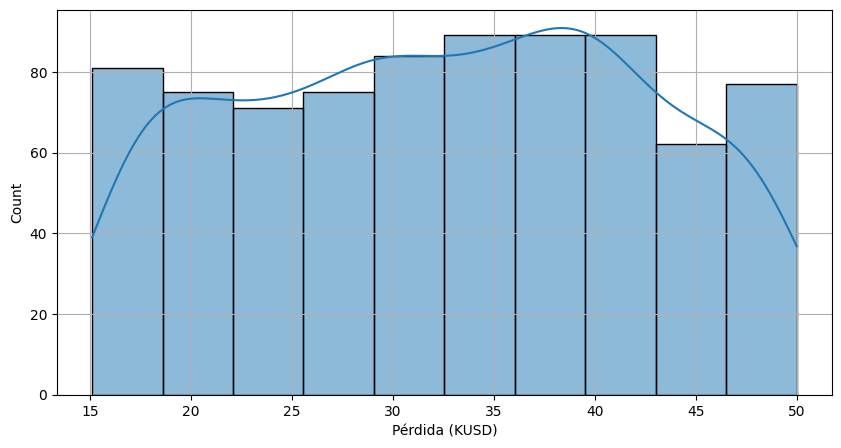

El número de datos por intervalo es:
[81 75 71 75 84 89 89 89 62 77]
Los intervalos inferiores:
[15.096  18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136
 46.5033]
Los intervalos superiores:
[18.5857 22.0754 25.5651 29.0548 32.5445 36.0342 39.5239 43.0136 46.5033
 49.993 ]
La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.56653093434344
La credibilidad es: 0.7126161490227079


np.float64(0.7126161490227079)

In [113]:
#Se procede del valor esperado de la varianza
Credibilidad(LDAo,LDAe)

###Itagui

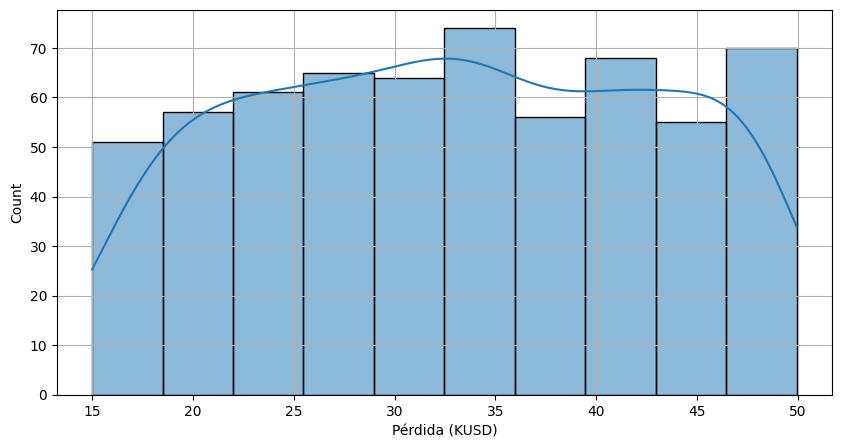

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


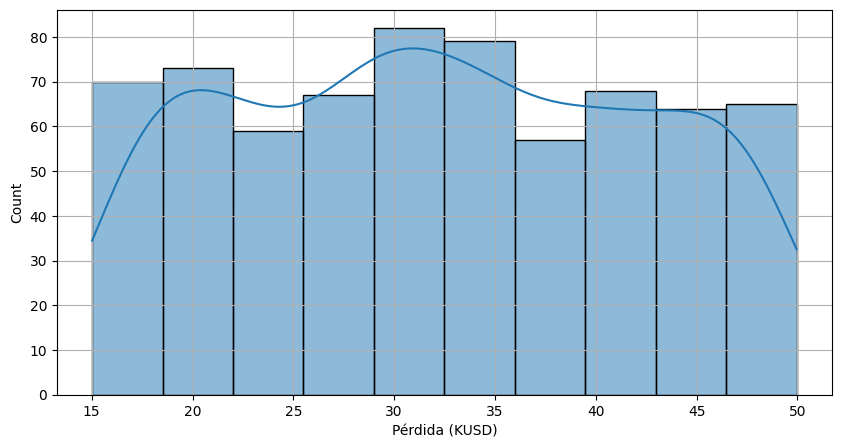

El número de datos por intervalo es:
[70 73 59 67 82 79 57 68 64 65]
Los intervalos inferiores:
[15.019  18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758
 46.4704]
Los intervalos superiores:
[18.5136 22.0082 25.5028 28.9974 32.492  35.9866 39.4812 42.9758 46.4704
 49.965 ]


In [114]:
#Se procede con la caracterización de la distribución de datos internos
XDBo=pd.read_excel(nxl,sheet_name=4) # Commented out the original line causing the error
LDAo=XDBo.iloc[:,5]
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
OpVaro,NPEo,NPNEo,NPCo=RiskParameters(LDAo)

#Se procede con la caracterización de la distribución de los datos externos - Itagui
XDBi=pd.read_excel(nxl,sheet_name=3) # Commented out the original line causing the error
LDAi=XDBi.iloc[:,4]
ui,sigmai,Casi,Kuri,dfi=caracterizacion(LDAi) # Added .dropna() to handle NaN values
OpVari,NPEi,NPNEi,NPCi=RiskParameters(LDAi) # Added .dropna() to handle NaN values

In [115]:
#Se procede del valor esperado de la varianza
NDo=len(LDAo);NDi=len(LDAi)
EPVi=(sigmao*NDo+sigmai*NDi)/(NDo+NDi)

#Se procede con la estimación del Valor Hipotetico de la Media
uhi=(uo*NDo+ui*NDi)/(NDo+NDi)
VHMi=((NDo*uo**2+NDi*ui**2)/(NDo+NDi))-uhi**2

#Se procede con la estimación del fc
fci=EPVi/VHMi

#Se procede con la estimación de la credibilidad
Cri=NDo/(NDo+fci)
print("La media de los datos internos es:",uo)
print("La media de los datos externos es:",ui)
print("La credibilidad es:",Cri)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.2467649122807
La credibilidad es: 0.8901234540257725


###Caldas

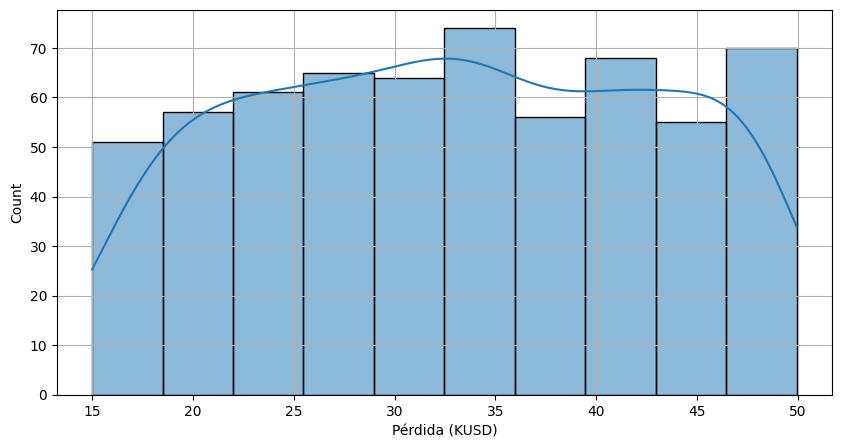

El número de datos por intervalo es:
[51 57 61 65 64 74 56 68 55 70]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]


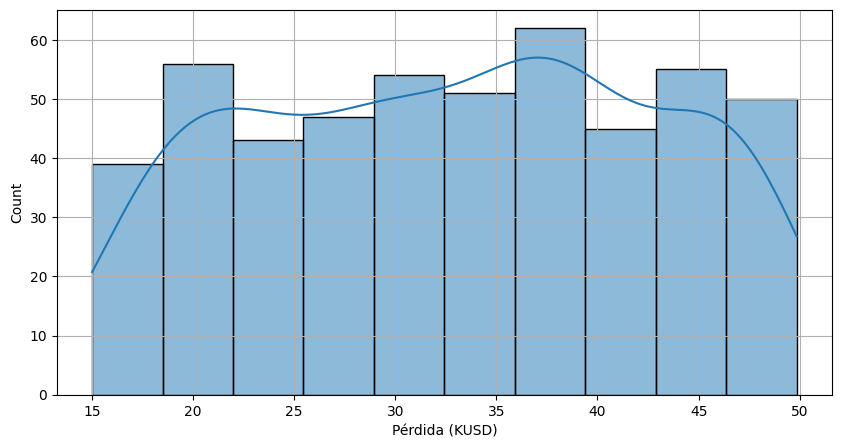

El número de datos por intervalo es:
[39 56 43 47 54 51 62 45 55 50]
Los intervalos inferiores:
[15.003 18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368]
Los intervalos superiores:
[18.488 21.973 25.458 28.943 32.428 35.913 39.398 42.883 46.368 49.853]


In [116]:
#Se procede con la caracterización de la distribución de datos internos
XDBo=pd.read_excel(nxl,sheet_name=4) # Commented out the original line causing the error
LDAo=XDBo.iloc[:,5]
uo,sigmao,Caso,Kuro,dfo=caracterizacion(LDAo)
OpVaro,NPEo,NPNEo,NPCo=RiskParameters(LDAo)

#Se procede con la caracterización de la distribución de los datos externos - bello
XDBc=pd.read_excel(nxl,sheet_name=0) # Commented out the original line causing the error
LDAc=XDBc.iloc[:,5]
uc,sigmac,Casc,Kurc,dfc=caracterizacion(LDAc)
OpVarc,NPEc,NPNEc,NPCc=RiskParameters(LDAc)

In [117]:
#Se procede del valor esperado de la varianza
NDo=len(LDAo);NDc=len(LDAc)
EPVc=(sigmao*NDo+sigmac*NDc)/(NDo+NDc)

#Se procede con la estimación del Valor Hipotetico de la Media
uhc=(uo*NDo+uc*NDc)/(NDo+NDc)
VHMc=((NDo*uo**2+NDc*uc**2)/(NDo+NDc))-uhc**2

#Se procede con la estimación del fc
fcc=EPVc/VHMc

#Se procede con la estimación de la credibilidad
Crc=NDo/(NDo+fcc)
print("La media de los datos internos es:",uo)
print("La media de los datos externos es:",uc)
print("La credibilidad es:",Crc)

La media de los datos internos es: 32.96582487922706
La media de los datos externos es: 32.9278406374502
La credibilidad es: 0.022050146729361828


In [118]:
import pandas as pd

# La lista de resultados que proporcionaste
resultados = [
    ['Bello', Cr * 100, fc],
    ['Medellín', Crm * 100, fcm],
    ['Envigado', Cre * 100, fce],
    ['Itagui', Cri * 100, fci],
    ['Caldas', Crc * 100, fcc]
]

# Opción 1: Crear el DataFrame directamente desde la lista (la más recomendada)
df_directo = pd.DataFrame(resultados, columns=['Sucursal', 'Credibilidad (%)', 'Factor de Credibilidad'])
print("DataFrame creado directamente desde la lista:")
display(df_directo)



DataFrame creado directamente desde la lista:


,Sucursal,Credibilidad (%),Factor de Credibilidad
0,Bello,2.205015,27542.077898
1,Medellín,99.999334,0.004139
2,Envigado,71.261615,250.436889
3,Itagui,89.012345,76.656035
4,Caldas,2.205015,27542.077898


##**2. Datos de integración y validación de variables estadisticas**

In [64]:
# @title Bello
LDAint_bello=np.copy(np.array(LDAo))   #Variable de Integración
LDAb=np.array(LDAb)

m_bello=0
for k in range(len(LDAb)):
  VP=np.exp(-0.5*((uo-LDAb[k,])/sigmao)**2)

  if VP>0.9:
      m_bello=m_bello+1   #Contador de cuantos datos integrados
      LDAin_bellot=np.append(LDAint_bello,LDAb[k])
      print("El dato a integrar es:",LDAb[k])

print("Los datos integrados son:",m_bello)

bello_integrated_count = m_bello
print(f"The count of patients from Bello with a membership value greater than 0.02 is: {bello_integrated_count}")

El dato a integrar es: 29.262
El dato a integrar es: 34.485
El dato a integrar es: 32.358
El dato a integrar es: 36.285
El dato a integrar es: 32.157
El dato a integrar es: 31.307
El dato a integrar es: 31.328
El dato a integrar es: 33.093
El dato a integrar es: 31.204
El dato a integrar es: 33.303
El dato a integrar es: 36.183
El dato a integrar es: 33.482
El dato a integrar es: 29.866
El dato a integrar es: 35.845
El dato a integrar es: 29.671
El dato a integrar es: 33.316
El dato a integrar es: 31.983
El dato a integrar es: 31.588
El dato a integrar es: 36.938
El dato a integrar es: 29.17
El dato a integrar es: 34.997
El dato a integrar es: 34.003
El dato a integrar es: 28.937
El dato a integrar es: 37.304
El dato a integrar es: 29.12
El dato a integrar es: 33.207
El dato a integrar es: 33.236
El dato a integrar es: 28.756
El dato a integrar es: 30.372
El dato a integrar es: 29.658
El dato a integrar es: 30.619
El dato a integrar es: 29.378
El dato a integrar es: 34.998
El dato a in

In [58]:
# @title Medellín
LDAint=np.copy(np.array(LDAo))   #Variable de Integración
LDAm=np.array(LDAm)

m1=0
for k in range(len(LDAm)):
  VP=np.exp(-0.5*((uo-LDAm[k,])/sigmao)**2)

  if VP>0.9:
      m1=m1+1   #Contador de cuantos datos integrados
      LDAint=np.append(LDAint,LDAm[k])
      print("El dato a integrar es:",LDAm[k])

print("Los datos integrados son:",m1)

medellin_integrated_count = m1
print(f"The count of patients from Medellín with a membership value greater than 0.9 is: {medellin_integrated_count}")

El dato a integrar es: 29
El dato a integrar es: 34
El dato a integrar es: 31
El dato a integrar es: 33
El dato a integrar es: 36
El dato a integrar es: 29
El dato a integrar es: 35
El dato a integrar es: 33
El dato a integrar es: 31
El dato a integrar es: 37
Los datos integrados son: 10
The count of patients from Medellín with a membership value greater than 0.9 is: 10


In [65]:
# @title Envigado
LDAint_envigado = np.copy(np.array(LDAo))   # Variable de Integración, starting with internal data
LDAe_array = np.array(LDAe)

m_envigado = 0
for k in range(len(LDAe_array)):
  VP_envigado = np.exp(-0.5*((uo-LDAe_array[k])/sigmao)**2)

  if VP_envigado > 0.9:
      m_envigado = m_envigado + 1   # Contador de cuantos datos integrados
      LDAint_envigado = np.append(LDAint_envigado, LDAe_array[k])
      print(f"El dato de Envigado a integrar es: {LDAe_array[k]}")

print(f"Los datos integrados de Envigado son: {m_envigado}")

envigado_integrated_count = m_envigado
print(f"The count of patients from Envigado with a membership value greater than 0.7 is: {envigado_integrated_count}")

El dato de Envigado a integrar es: 29.11
El dato de Envigado a integrar es: 32.877
El dato de Envigado a integrar es: 31.105
El dato de Envigado a integrar es: 28.763
El dato de Envigado a integrar es: 33.969
El dato de Envigado a integrar es: 30.239
El dato de Envigado a integrar es: 35.138
El dato de Envigado a integrar es: 32.412
El dato de Envigado a integrar es: 32.57
El dato de Envigado a integrar es: 29.314
El dato de Envigado a integrar es: 31.211
El dato de Envigado a integrar es: 30.065
El dato de Envigado a integrar es: 30.342
El dato de Envigado a integrar es: 29.469
El dato de Envigado a integrar es: 30.707
El dato de Envigado a integrar es: 33.059
El dato de Envigado a integrar es: 30.501
El dato de Envigado a integrar es: 37.054
El dato de Envigado a integrar es: 28.752
El dato de Envigado a integrar es: 35.948
El dato de Envigado a integrar es: 35.703
El dato de Envigado a integrar es: 31.248
El dato de Envigado a integrar es: 35.839
El dato de Envigado a integrar es: 2

In [60]:
# @title Itagui
LDAint_itagui = np.copy(np.array(LDAo))   # Variable de Integración, starting with internal data
LDAi_array = np.array(LDAi)

m_itagui = 0
for k in range(len(LDAi_array)):
  VP_itagui = np.exp(-0.5*((uo-LDAi_array[k])/sigmao)**2)

  if VP_itagui > 0.9:
      m_itagui = m_itagui + 1   # Contador de cuantos datos integrados
      LDAint_itagui = np.append(LDAint_itagui, LDAi_array[k])
      print(f"El dato de Itagui a integrar es: {LDAi_array[k]}")

print(f"Los datos integrados de Itagui son: {m_itagui}")

itagui_integrated_count = m_itagui
print(f"The count of patients from Itagui with a membership value greater than 0.9 is: {itagui_integrated_count}")

El dato de Itagui a integrar es: 34.553
El dato de Itagui a integrar es: 33.849
El dato de Itagui a integrar es: 29.793
El dato de Itagui a integrar es: 36.061
El dato de Itagui a integrar es: 30.389
El dato de Itagui a integrar es: 36.099
El dato de Itagui a integrar es: 29.835
El dato de Itagui a integrar es: 35.745
El dato de Itagui a integrar es: 30.686
El dato de Itagui a integrar es: 33.105
El dato de Itagui a integrar es: 32.894
El dato de Itagui a integrar es: 33.104
El dato de Itagui a integrar es: 30.563
El dato de Itagui a integrar es: 33.985
El dato de Itagui a integrar es: 30.262
El dato de Itagui a integrar es: 34.574
El dato de Itagui a integrar es: 33.256
El dato de Itagui a integrar es: 36.043
El dato de Itagui a integrar es: 30.755
El dato de Itagui a integrar es: 33.372
El dato de Itagui a integrar es: 35.562
El dato de Itagui a integrar es: 30.391
El dato de Itagui a integrar es: 37.269
El dato de Itagui a integrar es: 31.797
El dato de Itagui a integrar es: 34.344


In [61]:
# @title Caldas
LDAint_caldas = np.copy(np.array(LDAo))   # Variable de Integración, starting with internal data
LDAc_array = np.array(LDAc)

m_caldas = 0
for k in range(len(LDAc_array)):
  VP_caldas = np.exp(-0.5*((uo-LDAc_array[k])/sigmao)**2)

  if VP_caldas > 0.9:
      m_caldas = m_caldas + 1   # Contador de cuantos datos integrados
      LDAint_caldas = np.append(LDAint_caldas, LDAc_array[k])
      print(f"El dato de Caldas a integrar es: {LDAc_array[k]}")

print(f"Los datos integrados de Caldas son: {m_caldas}")

caldas_integrated_count = m_caldas
print(f"The count of patients from Caldas with a membership value greater than 0.9 is: {caldas_integrated_count}")

El dato de Caldas a integrar es: 29.262
El dato de Caldas a integrar es: 34.485
El dato de Caldas a integrar es: 32.358
El dato de Caldas a integrar es: 36.285
El dato de Caldas a integrar es: 32.157
El dato de Caldas a integrar es: 31.307
El dato de Caldas a integrar es: 31.328
El dato de Caldas a integrar es: 33.093
El dato de Caldas a integrar es: 31.204
El dato de Caldas a integrar es: 33.303
El dato de Caldas a integrar es: 36.183
El dato de Caldas a integrar es: 33.482
El dato de Caldas a integrar es: 29.866
El dato de Caldas a integrar es: 35.845
El dato de Caldas a integrar es: 29.671
El dato de Caldas a integrar es: 33.316
El dato de Caldas a integrar es: 31.983
El dato de Caldas a integrar es: 31.588
El dato de Caldas a integrar es: 36.938
El dato de Caldas a integrar es: 29.17
El dato de Caldas a integrar es: 34.997
El dato de Caldas a integrar es: 34.003
El dato de Caldas a integrar es: 28.937
El dato de Caldas a integrar es: 37.304
El dato de Caldas a integrar es: 29.12
El

Análisis de los Datos De lo anterior podemos observar, que la credibilidad de los datos de bello y bello es de 2,2%, lo que indica que más del 2% de los datos pueden ser integrados a la base de datos interna. La de envigado fue de 71,3%, indicando que más del 70% de los datos se puede integrar. Para Itagui se tiene que el 89% de los datos se puede integrar. Por ultimo, en Medellín se tiene que el 99% de los datos se puede integrar.

De acuerdo con la media de los datos integrados, podemos observar que la mayoria tuvo una discrepancia cercana al 1%, lo que corroborá el nivel de credibilidad alcanzado por la base de datos externa, frente a la base de datos interna. Excepto la base de Medellín, que obtuvo una discrepancia de más del 350%, lo que indica que no es confiable el nivel de credibilidad alcanzado.

##**3. Método de Aceptación y Rechazo I**

Integrating Bello data points based on Acceptance-Rejection criteria (VPo > VPb):
  Integrated data point from Bello: 19.375
  Integrated data point from Bello: 43.115
  Integrated data point from Bello: 21.23
  Integrated data point from Bello: 49.781
  Integrated data point from Bello: 45.16
  Integrated data point from Bello: 45.977
  Integrated data point from Bello: 17.449
  Integrated data point from Bello: 47.579
  Integrated data point from Bello: 46.815
  Integrated data point from Bello: 34.485
  Integrated data point from Bello: 40.421
  Integrated data point from Bello: 45.172
  Integrated data point from Bello: 39.682
  Integrated data point from Bello: 36.285
  Integrated data point from Bello: 15.325
  Integrated data point from Bello: 43.752
  Integrated data point from Bello: 37.96
  Integrated data point from Bello: 16.075
  Integrated data point from Bello: 15.003
  Integrated data point from Bello: 46.328
  Integrated data point from Bello: 49.559
  Integrated data 

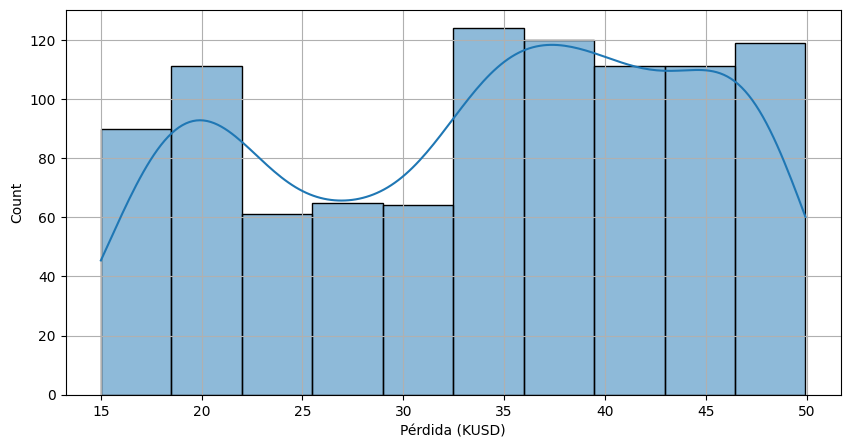

El número de datos por intervalo es:
[ 90 111  61  65  64 124 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

--- Integrated Bello Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Bello data (uint_bello) is: 33.79094754098361
The percentage discrepancy between uo and uint_bello is: 2.50%


In [124]:
# @title Bello
LDAint_bello = np.copy(LDAo) # 1. Initialize LDAint_bello by copying LDAo

# 2. Convert LDAb to a NumPy array for consistent indexing
LDAb_array = np.array(LDAb)

print("Integrating Bello data points based on Acceptance-Rejection criteria (VPo > VPb):")
# 3. Iterate through each data point in the LDAb NumPy array
for k in range(len(LDAb_array)):
  data_point = LDAb_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPb with respect to Bello data's distribution
  VPb = np.exp(-0.5*((ub-data_point)/sigmab)**2)

  # 6. Compare VPo and VPb. If VPo > VPb, append the current data point from LDAb to LDAint_bello
  if VPo > VPb:
      LDAint_bello = np.append(LDAint_bello, data_point)
      print(f"  Integrated data point from Bello: {data_point}")

# 7. Characterize the integrated Bello data
uint_bello, sigmaint_bello, Casint_bello, Kurint_bello, dfint_bello = caracterizacion(LDAint_bello)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Bello Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Bello data (uint_bello)
print(f"The mean of the integrated Bello data (uint_bello) is: {uint_bello}")
# 10. Calculate and print the percentage discrepancy between uo and uint_bello
disc_u_bello = np.abs((uo - uint_bello) / uo) * 100
print(f"The percentage discrepancy between uo and uint_bello is: {disc_u_bello:.2f}%")

Integrating Medellín data points based on Acceptance-Rejection criteria (VPo > VPm):
  Integrated data point from Medellín: 17
  Integrated data point from Medellín: 29
  Integrated data point from Medellín: 24
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 45
  Integrated data point from Medellín: 43
  Integrated data point from Medellín: 34
  Integrated data point from Medellín: 21
  Integrated data point from Medellín: 31
  Integrated data point from Medellín: 28
  Integrated data point from Medellín: 18
  Integrated data point from Medellín: 33
  Integrated data point from Medellín: 23
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 22
  Integrated data point from Medellín: 36
  Integrated data point from Medellín: 29
  Integrated data point from Medellín: 35
  Integrated data point from Medellín: 33
  Integrated data point from Medellín: 47
  Integrated data point from Mede

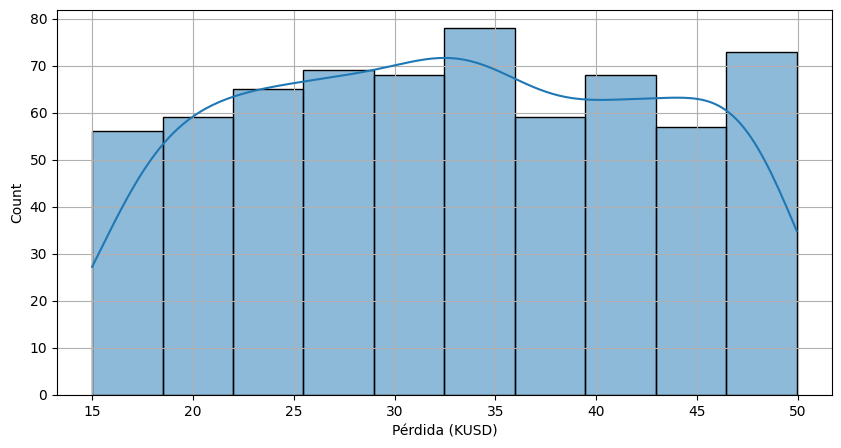

El número de datos por intervalo es:
[56 59 65 69 68 78 59 68 57 73]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

--- Integrated Medellín Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Medellín data (uint_medellin) is: 32.83255628834356
The percentage discrepancy between uo and uint_medellin is: 0.40%


In [119]:
# @title Medellín
LDAint_medellin = np.copy(LDAo) # 1. Initialize LDAint_medellin by copying LDAo

# Ensure LDAm is a numpy array for consistent indexing
LDAm_array = np.array(LDAm)

print("Integrating Medellín data points based on Acceptance-Rejection criteria (VPo > VPm):")
# 2. Iterate through each data point in LDAm
for k in range(len(LDAm_array)):
  data_point = LDAm_array[k]

  # 3. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 4. Calculate VPm with respect to Medellín data's distribution
  VPm = np.exp(-0.5*((um-data_point)/sigmam)**2)

  # 5. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo > VPm:
      LDAint_medellin = np.append(LDAint_medellin, data_point)
      print(f"  Integrated data point from Medellín: {data_point}")

# 6. Characterize the integrated Medellín data
uint_medellin, sigmaint_medellin, Casint_medellin, Kurint_medellin, dfint_medellin = caracterizacion(LDAint_medellin)

# 7. Print the requested statistics
print("\n--- Integrated Medellín Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
print(f"The mean of the integrated Medellín data (uint_medellin) is: {uint_medellin}")
disc_u_medellin = np.abs((uo - uint_medellin) / uo) * 100
print(f"The percentage discrepancy between uo and uint_medellin is: {disc_u_medellin:.2f}%")


Integrating Envigado data points based on Acceptance-Rejection criteria (VPo > VPe):
  Integrated data point from Envigado: 3522.31
  Integrated data point from Envigado: 2737.2400000000002
  Integrated data point from Envigado: 3480.3230000000003
  Integrated data point from Envigado: 3047.904
  Integrated data point from Envigado: 2275.9230000000002
  Integrated data point from Envigado: 3602.26
  Integrated data point from Envigado: 2630.793
  Integrated data point from Envigado: 2671.3500000000004
  Integrated data point from Envigado: 3594.6780000000003
  Integrated data point from Envigado: 3608.673
  Integrated data point from Envigado: 1977.1319999999998
  Integrated data point from Envigado: 2306.288
  Integrated data point from Envigado: 936.96
  Integrated data point from Envigado: 2096.312
  Integrated data point from Envigado: 3152.3109999999997
  Integrated data point from Envigado: 1563.38
  Integrated data point from Envigado: 2481.48
  Integrated data point from Enviga

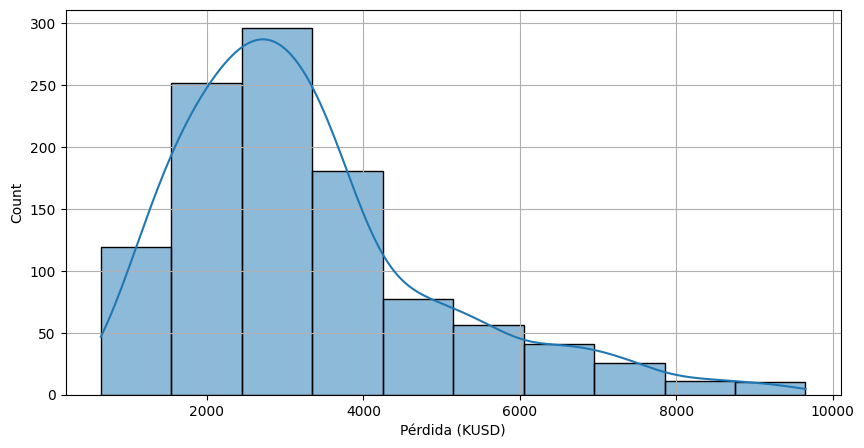

El número de datos por intervalo es:
[119 252 296 181  77  56  41  26  11  10]
Los intervalos inferiores:
[ 644.28   1544.8972 2445.5144 3346.1316 4246.7488 5147.366  6047.9832
 6948.6004 7849.2176 8749.8348]
Los intervalos superiores:
[1544.8972 2445.5144 3346.1316 4246.7488 5147.366  6047.9832 6948.6004
 7849.2176 8749.8348 9650.452 ]

--- Integrated Envigado Data Statistics ---
The mean of the observed internal data (uo) is: 3797.8904692431565
The mean of the integrated Envigado data (uint_envigado) is: 3269.0441595884
The percentage discrepancy between uo and uint_envigado is: 13.92%


In [24]:
# @title Envigado
LDAint_envigado = np.copy(LDAo) # 1. Initialize LDAint_envigado by copying LDAo

# 2. Convert LDAe to a NumPy array for consistent indexing
LDAe_array = np.array(LDAe)

print("Integrating Envigado data points based on Acceptance-Rejection criteria (VPo > VPe):")
# 3. Iterate through each data point in the LDAe NumPy array
for k in range(len(LDAe_array)):
  data_point = LDAe_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPe with respect to Envigado data's distribution
  VPe = np.exp(-0.5*((ue-data_point)/sigmae)**2)

  # 6. Compare VPo and VPe. If VPo > VPe, append the current data point from LDAe to LDAint_envigado
  if VPo > VPe:
      LDAint_envigado = np.append(LDAint_envigado, data_point)
      print(f"  Integrated data point from Envigado: {data_point}")

# 7. Characterize the integrated Envigado data
uint_envigado, sigmaint_envigado, Casint_envigado, Kurint_envigado, dfint_envigado = caracterizacion(LDAint_envigado)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Envigado Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Envigado data (uint_envigado)
print(f"The mean of the integrated Envigado data (uint_envigado) is: {uint_envigado}")
# 10. Calculate and print the percentage discrepancy between uo and uint_envigado
disc_u_envigado = np.abs((uo - uint_envigado) / uo) * 100
print(f"The percentage discrepancy between uo and uint_envigado is: {disc_u_envigado:.2f}%")

Integrating Itagui data points based on Acceptance-Rejection criteria (VPo > VPi):
  Integrated data point from Itagui: 239.4
  Integrated data point from Itagui: 251.475
  Integrated data point from Itagui: 272.78
  Integrated data point from Itagui: 250.73300000000003
  Integrated data point from Itagui: 271.44
  Integrated data point from Itagui: 233.74400000000003
  Integrated data point from Itagui: 250.79999999999998
  Integrated data point from Itagui: 231.705
  Integrated data point from Itagui: 244.41899999999998
  Integrated data point from Itagui: 241.044
  Integrated data point from Itagui: 239.299
  Integrated data point from Itagui: 247.02
  Integrated data point from Itagui: 240.7
  Integrated data point from Itagui: 245.03999999999996
  Integrated data point from Itagui: 246.231
  Integrated data point from Itagui: 270.48
  Integrated data point from Itagui: 240.499
  Integrated data point from Itagui: 247.922
  Integrated data point from Itagui: 278.103
  Integrated da

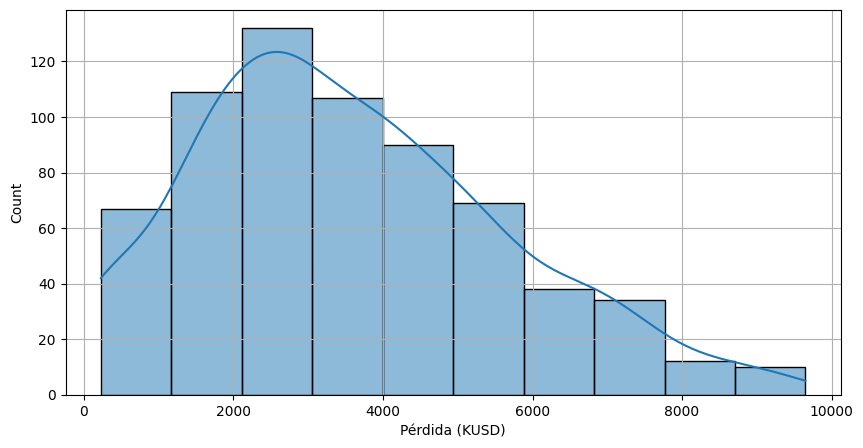

El número de datos por intervalo es:
[ 67 109 132 107  90  69  38  34  12  10]
Los intervalos inferiores:
[ 226.786  1169.1526 2111.5192 3053.8858 3996.2524 4938.619  5880.9856
 6823.3522 7765.7188 8708.0854]
Los intervalos superiores:
[1169.1526 2111.5192 3053.8858 3996.2524 4938.619  5880.9856 6823.3522
 7765.7188 8708.0854 9650.452 ]

--- Integrated Itagui Data Statistics ---
The mean of the observed internal data (uo) is: 3797.8904692431565
The mean of the integrated Itagui data (uint_itagui) is: 3591.3733368263474
The percentage discrepancy between uo and uint_itagui is: 5.44%


In [25]:
# @title Itagui
LDAint_itagui = np.copy(LDAo) # 1. Initialize LDAint_itagui by copying LDAo

# 2. Convert LDAi to a NumPy array for consistent indexing
LDAi_array = np.array(LDAi)

print("Integrating Itagui data points based on Acceptance-Rejection criteria (VPo > VPi):")
# 3. Iterate through each data point in the LDAi NumPy array
for k in range(len(LDAi_array)):
  data_point = LDAi_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPi with respect to Itagui data's distribution
  VPi = np.exp(-0.5*((ui-data_point)/sigmai)**2)

  # 6. Compare VPo and VPi. If VPo > VPi, append the current data point from LDAi to LDAint_itagui
  if VPo > VPi:
      LDAint_itagui = np.append(LDAint_itagui, data_point)
      print(f"  Integrated data point from Itagui: {data_point}")

# 7. Characterize the integrated Itagui data
uint_itagui, sigmaint_itagui, Casint_itagui, Kurint_itagui, dfint_itagui = caracterizacion(LDAint_itagui)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Itagui Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Itagui data (uint_itagui)
print(f"The mean of the integrated Itagui data (uint_itagui) is: {uint_itagui}")
# 10. Calculate and print the percentage discrepancy between uo and uint_itagui
disc_u_itagui = np.abs((uo - uint_itagui) / uo) * 100
print(f"The percentage discrepancy between uo and uint_itagui is: {disc_u_itagui:.2f}%")

Integrating Caldas data points based on Acceptance-Rejection criteria (VPo > VPc):
  Integrated data point from Caldas: 3235.625
  Integrated data point from Caldas: 2586.9
  Integrated data point from Caldas: 2207.92
  Integrated data point from Caldas: 3584.232
  Integrated data point from Caldas: 3070.8799999999997
  Integrated data point from Caldas: 3335.445
  Integrated data point from Caldas: 3123.371
  Integrated data point from Caldas: 2712.003
  Integrated data point from Caldas: 3698.3849999999998
  Integrated data point from Caldas: 2384.839
  Integrated data point from Caldas: 3412.652
  Integrated data point from Caldas: 2685.714
  Integrated data point from Caldas: 3229.365
  Integrated data point from Caldas: 3482.496
  Integrated data point from Caldas: 1976.925
  Integrated data point from Caldas: 1632.28
  Integrated data point from Caldas: 2547.4
  Integrated data point from Caldas: 1961.1499999999999
  Integrated data point from Caldas: 2940.588
  Integrated data p

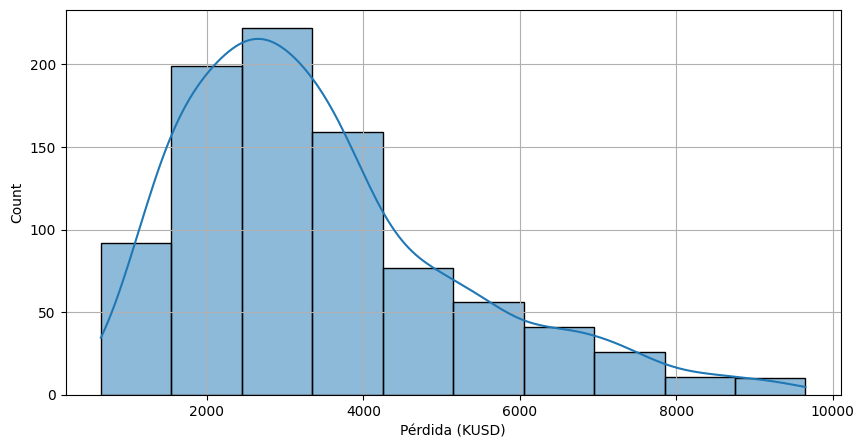

El número de datos por intervalo es:
[ 92 199 222 159  77  56  41  26  11  10]
Los intervalos inferiores:
[ 644.28   1544.8972 2445.5144 3346.1316 4246.7488 5147.366  6047.9832
 6948.6004 7849.2176 8749.8348]
Los intervalos superiores:
[1544.8972 2445.5144 3346.1316 4246.7488 5147.366  6047.9832 6948.6004
 7849.2176 8749.8348 9650.452 ]

--- Integrated Caldas Data Statistics ---
The mean of the observed internal data (uo) is: 3797.8904692431565
The mean of the integrated Caldas data (uint_caldas) is: 3428.326786786114
The percentage discrepancy between uo and uint_caldas is: 9.73%


In [26]:
# @title Caldas
LDAint_caldas = np.copy(LDAo) # 1. Initialize LDAint_caldas by copying LDAo

# 2. Convert LDAc to a NumPy array for consistent indexing
LDAc_array = np.array(LDAc)

print("Integrating Caldas data points based on Acceptance-Rejection criteria (VPo > VPc):")
# 3. Iterate through each data point in the LDAc NumPy array
for k in range(len(LDAc_array)):
  data_point = LDAc_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPc with respect to Caldas data's distribution
  VPc = np.exp(-0.5*((uc-data_point)/sigmac)**2)

  # 6. Compare VPo and VPc. If VPo > VPc, append the current data point from LDAc to LDAint_caldas
  if VPo > VPc:
      LDAint_caldas = np.append(LDAint_caldas, data_point)
      print(f"  Integrated data point from Caldas: {data_point}")

# 7. Characterize the integrated Caldas data
uint_caldas, sigmaint_caldas, Casint_caldas, Kurint_caldas, dfint_caldas = caracterizacion(LDAint_caldas)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Caldas Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Caldas data (uint_caldas)
print(f"The mean of the integrated Caldas data (uint_caldas) is: {uint_caldas}")
# 10. Calculate and print the percentage discrepancy between uo and uint_caldas
disc_u_caldas = np.abs((uo - uint_caldas) / uo) * 100
print(f"The percentage discrepancy between uo and uint_caldas is: {disc_u_caldas:.2f}%")

**Análisis de los Datos** De lo anterior podemos observar, la discrepancia de los datos de caldas fue de 9,73%, indicando que es una base de datos confiable

La de Itagui fue de 5,44%, indicando que es una de las más confiables para la integración.

Para Envigado se tiene el 13% de discrepancia, por lo que se concluye de que apesar de no ser menor a 10 tuvo muy buen desempeño.

Para medellín fue de 0.40%, indicando que es la base más confiable para hacer la integración.

Por ultimo, en Bello la discepancia fue de 2,5%, lo que indica que fue la segunda base más confiable para integrar.

##**3. Método de Aceptación y Rechazo II**

Integrating Bello data points based on Acceptance-Rejection criteria (VPo > VPb):
  Integrated data point from Bello: 19.375
  Integrated data point from Bello: 43.115
  Integrated data point from Bello: 21.23
  Integrated data point from Bello: 49.781
  Integrated data point from Bello: 45.16
  Integrated data point from Bello: 45.977
  Integrated data point from Bello: 24.707
  Integrated data point from Bello: 17.449
  Integrated data point from Bello: 47.579
  Integrated data point from Bello: 29.262
  Integrated data point from Bello: 46.815
  Integrated data point from Bello: 27.455
  Integrated data point from Bello: 34.485
  Integrated data point from Bello: 40.421
  Integrated data point from Bello: 45.172
  Integrated data point from Bello: 39.682
  Integrated data point from Bello: 32.358
  Integrated data point from Bello: 36.285
  Integrated data point from Bello: 32.157
  Integrated data point from Bello: 27.207
  Integrated data point from Bello: 31.307
  Integrated data

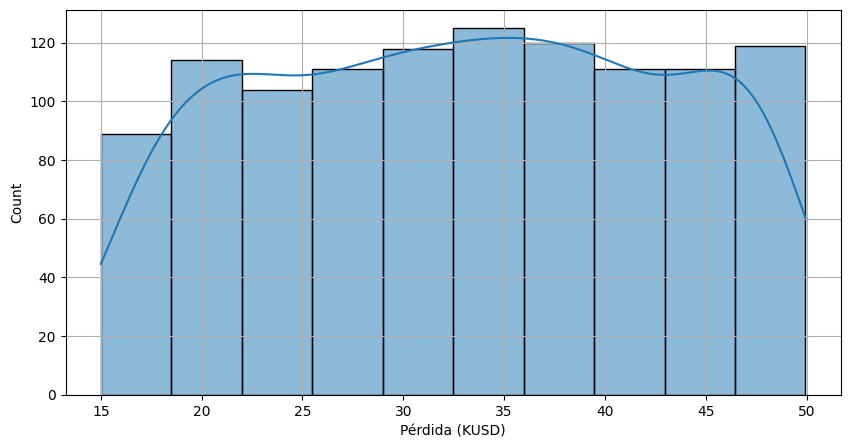

El número de datos por intervalo es:
[ 89 114 104 111 118 125 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

--- Integrated Bello Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Bello data (uint_bello) is: 32.968653208556155
The percentage discrepancy between uo and uint_bello is: 0.01%


In [126]:
# @title Bello
LDAint_bello = np.copy(LDAo) # 1. Initialize LDAint_bello by copying LDAo

# 2. Convert LDAb to a NumPy array for consistent indexing
LDAb_array = np.array(LDAb)

print("Integrating Bello data points based on Acceptance-Rejection criteria (VPo > VPb):")
# 3. Iterate through each data point in the LDAb NumPy array
for k in range(len(LDAb_array)):
  data_point = LDAb_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPb with respect to Bello data's distribution
  VPb = np.exp(-0.5*((ub-data_point)/sigmab)**2)

  al=np.random.random()  #Aceptación y Rechazo II
  # 6. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo/VPm > al:
      LDAint_bello = np.append(LDAint_bello, data_point)
      print(f"  Integrated data point from Bello: {data_point}")

# 7. Characterize the integrated Bello data
uint_bello, sigmaint_bello, Casint_bello, Kurint_bello, dfint_bello = caracterizacion(LDAint_bello)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Bello Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Bello data (uint_bello)
print(f"The mean of the integrated Bello data (uint_bello) is: {uint_bello}")
# 10. Calculate and print the percentage discrepancy between uo and uint_bello
disc_u_bello = np.abs((uo - uint_bello) / uo) * 100
print(f"The percentage discrepancy between uo and uint_bello is: {disc_u_bello:.2f}%")

Integrating Medellín data points based on Acceptance-Rejection criteria (VPo > VPm):
  Integrated data point from Medellín: 17
  Integrated data point from Medellín: 29
  Integrated data point from Medellín: 59
  Integrated data point from Medellín: 24
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 45
  Integrated data point from Medellín: 43
  Integrated data point from Medellín: 34
  Integrated data point from Medellín: 21
  Integrated data point from Medellín: 31
  Integrated data point from Medellín: 11
  Integrated data point from Medellín: 28
  Integrated data point from Medellín: 18
  Integrated data point from Medellín: 33
  Integrated data point from Medellín: 23
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 26
  Integrated data point from Medellín: 22
  Integrated data point from Medellín: 36
  Integrated data point from Medellín: 48
  Integrated data point from Medellín: 29
  Integrated data point from Mede

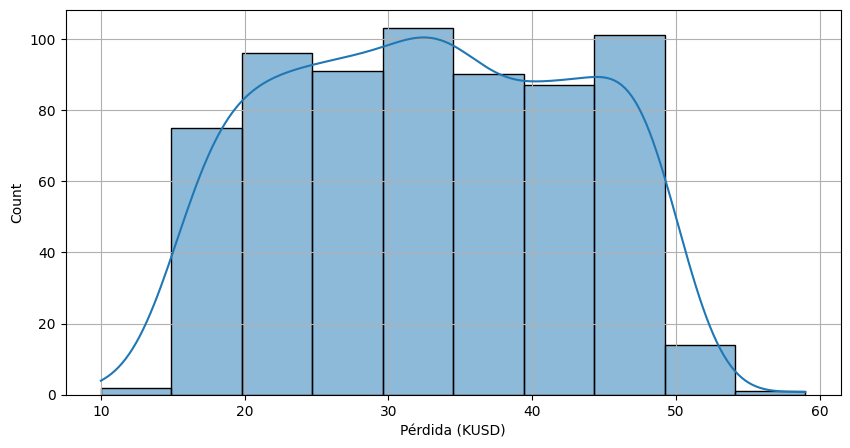

El número de datos por intervalo es:
[  2  75  96  91 103  90  87 101  14   1]
Los intervalos inferiores:
[10.  14.9 19.8 24.7 29.6 34.5 39.4 44.3 49.2 54.1]
Los intervalos superiores:
[14.9 19.8 24.7 29.6 34.5 39.4 44.3 49.2 54.1 59. ]

--- Integrated Medellín Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Medellín data (uint_medellin) is: 32.88151515151515
The percentage discrepancy between uo and uint_medellin is: 0.26%


In [120]:
# @title Medellín
LDAint_medellin = np.copy(LDAo) # 1. Initialize LDAint_medellin by copying LDAo

# Ensure LDAm is a numpy array for consistent indexing
LDAm_array = np.array(LDAm)

print("Integrating Medellín data points based on Acceptance-Rejection criteria (VPo > VPm):")
# 2. Iterate through each data point in LDAm
for k in range(len(LDAm_array)):
  data_point = LDAm_array[k]

  # 3. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 4. Calculate VPm with respect to Medellín data's distribution
  VPm = np.exp(-0.5*((um-data_point)/sigmam)**2)

  al=np.random.random()  #Aceptación y Rechazo II
  # 5. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo/VPm > al:
      LDAint_medellin = np.append(LDAint_medellin, data_point)
      print(f"  Integrated data point from Medellín: {data_point}")

# 6. Characterize the integrated Medellín data
uint_medellin, sigmaint_medellin, Casint_medellin, Kurint_medellin, dfint_medellin = caracterizacion(LDAint_medellin)

# 7. Print the requested statistics
print("\n--- Integrated Medellín Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
print(f"The mean of the integrated Medellín data (uint_medellin) is: {uint_medellin}")
disc_u_medellin = np.abs((uo - uint_medellin) / uo) * 100
print(f"The percentage discrepancy between uo and uint_medellin is: {disc_u_medellin:.2f}%")


Integrating Envigado data points based on Acceptance-Rejection criteria (VPo > VPe):
  Integrated data point from Envigado: 26.921
  Integrated data point from Envigado: 29.11
  Integrated data point from Envigado: 32.877
  Integrated data point from Envigado: 49.109
  Integrated data point from Envigado: 31.105
  Integrated data point from Envigado: 28.763
  Integrated data point from Envigado: 20.052
  Integrated data point from Envigado: 33.969
  Integrated data point from Envigado: 39.155
  Integrated data point from Envigado: 30.239
  Integrated data point from Envigado: 16.19
  Integrated data point from Envigado: 40.148
  Integrated data point from Envigado: 20.082
  Integrated data point from Envigado: 46.146
  Integrated data point from Envigado: 41.479
  Integrated data point from Envigado: 35.138
  Integrated data point from Envigado: 49.993
  Integrated data point from Envigado: 32.412
  Integrated data point from Envigado: 45.399
  Integrated data point from Envigado: 32.5

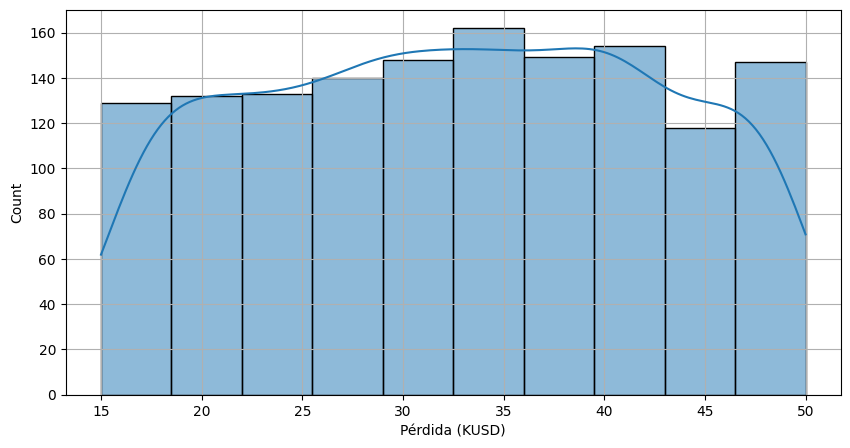

El número de datos por intervalo es:
[129 132 133 140 148 162 149 154 118 147]
Los intervalos inferiores:
[15.003 18.502 22.001 25.5   28.999 32.498 35.997 39.496 42.995 46.494]
Los intervalos superiores:
[18.502 22.001 25.5   28.999 32.498 35.997 39.496 42.995 46.494 49.993]

--- Integrated Envigado Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Envigado data (uint_envigado) is: 32.7581947592068
The percentage discrepancy between uo and uint_envigado is: 0.63%


In [125]:
# @title Envigado
LDAint_envigado = np.copy(LDAo) # 1. Initialize LDAint_envigado by copying LDAo

# 2. Convert LDAe to a NumPy array for consistent indexing
LDAe_array = np.array(LDAe)

print("Integrating Envigado data points based on Acceptance-Rejection criteria (VPo > VPe):")
# 3. Iterate through each data point in the LDAe NumPy array
for k in range(len(LDAe_array)):
  data_point = LDAe_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPe with respect to Envigado data's distribution
  VPe = np.exp(-0.5*((ue-data_point)/sigmae)**2)

  al=np.random.random()  #Aceptación y Rechazo II
  # 6. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo/VPm > al:
      LDAint_envigado = np.append(LDAint_envigado, data_point)
      print(f"  Integrated data point from Envigado: {data_point}")

# 7. Characterize the integrated Envigado data
uint_envigado, sigmaint_envigado, Casint_envigado, Kurint_envigado, dfint_envigado = caracterizacion(LDAint_envigado)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Envigado Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Envigado data (uint_envigado)
print(f"The mean of the integrated Envigado data (uint_envigado) is: {uint_envigado}")
# 10. Calculate and print the percentage discrepancy between uo and uint_envigado
disc_u_envigado = np.abs((uo - uint_envigado) / uo) * 100
print(f"The percentage discrepancy between uo and uint_envigado is: {disc_u_envigado:.2f}%")

Integrating Itagui data points based on Acceptance-Rejection criteria (VPo > VPi):
  Integrated data point from Itagui: 25.563
  Integrated data point from Itagui: 49.786
  Integrated data point from Itagui: 49.004
  Integrated data point from Itagui: 47.335
  Integrated data point from Itagui: 34.553
  Integrated data point from Itagui: 33.849
  Integrated data point from Itagui: 28.181
  Integrated data point from Itagui: 39.515
  Integrated data point from Itagui: 22.048
  Integrated data point from Itagui: 29.793
  Integrated data point from Itagui: 44.89
  Integrated data point from Itagui: 46.988
  Integrated data point from Itagui: 18.118
  Integrated data point from Itagui: 18.572
  Integrated data point from Itagui: 47.433
  Integrated data point from Itagui: 22.988
  Integrated data point from Itagui: 21.106
  Integrated data point from Itagui: 24.209
  Integrated data point from Itagui: 36.061
  Integrated data point from Itagui: 46.955
  Integrated data point from Itagui: 3

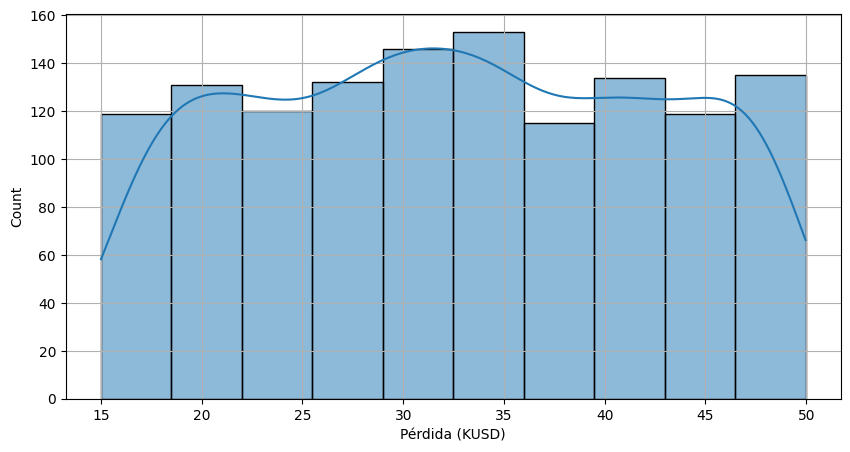

El número de datos por intervalo es:
[119 131 120 132 146 153 115 134 119 135]
Los intervalos inferiores:
[15.003  18.4992 21.9954 25.4916 28.9878 32.484  35.9802 39.4764 42.9726
 46.4688]
Los intervalos superiores:
[18.4992 21.9954 25.4916 28.9878 32.484  35.9802 39.4764 42.9726 46.4688
 49.965 ]

--- Integrated Itagui Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Itagui data (uint_itagui) is: 32.599288803680984
The percentage discrepancy between uo and uint_itagui is: 1.11%


In [122]:
# @title Itagui
LDAint_itagui = np.copy(LDAo) # 1. Initialize LDAint_itagui by copying LDAo

# 2. Convert LDAi to a NumPy array for consistent indexing
LDAi_array = np.array(LDAi)

print("Integrating Itagui data points based on Acceptance-Rejection criteria (VPo > VPi):")
# 3. Iterate through each data point in the LDAi NumPy array
for k in range(len(LDAi_array)):
  data_point = LDAi_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPi with respect to Itagui data's distribution
  VPi = np.exp(-0.5*((ui-data_point)/sigmai)**2)

  al=np.random.random()  #Aceptación y Rechazo II
  # 6. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo/VPm > al:
      LDAint_itagui = np.append(LDAint_itagui, data_point)
      print(f"  Integrated data point from Itagui: {data_point}")

# 7. Characterize the integrated Itagui data
uint_itagui, sigmaint_itagui, Casint_itagui, Kurint_itagui, dfint_itagui = caracterizacion(LDAint_itagui)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Itagui Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Itagui data (uint_itagui)
print(f"The mean of the integrated Itagui data (uint_itagui) is: {uint_itagui}")
# 10. Calculate and print the percentage discrepancy between uo and uint_itagui
disc_u_itagui = np.abs((uo - uint_itagui) / uo) * 100
print(f"The percentage discrepancy between uo and uint_itagui is: {disc_u_itagui:.2f}%")

Integrating Caldas data points based on Acceptance-Rejection criteria (VPo > VPc):
  Integrated data point from Caldas: 19.375
  Integrated data point from Caldas: 43.115
  Integrated data point from Caldas: 21.23
  Integrated data point from Caldas: 49.781
  Integrated data point from Caldas: 45.16
  Integrated data point from Caldas: 45.977
  Integrated data point from Caldas: 24.707
  Integrated data point from Caldas: 17.449
  Integrated data point from Caldas: 47.579
  Integrated data point from Caldas: 29.262
  Integrated data point from Caldas: 46.815
  Integrated data point from Caldas: 27.455
  Integrated data point from Caldas: 34.485
  Integrated data point from Caldas: 40.421
  Integrated data point from Caldas: 45.172
  Integrated data point from Caldas: 39.682
  Integrated data point from Caldas: 32.358
  Integrated data point from Caldas: 36.285
  Integrated data point from Caldas: 32.157
  Integrated data point from Caldas: 27.207
  Integrated data point from Caldas: 31

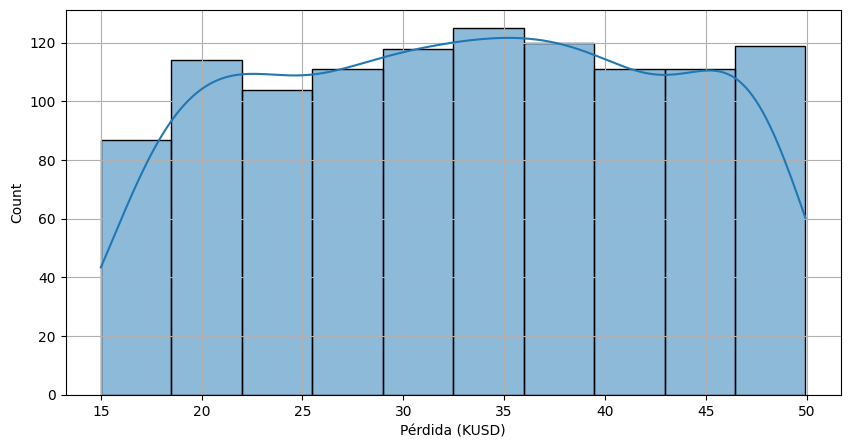

El número de datos por intervalo es:
[ 87 114 104 111 118 125 120 111 111 119]
Los intervalos inferiores:
[15.003  18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558
 46.4499]
Los intervalos superiores:
[18.4971 21.9912 25.4853 28.9794 32.4735 35.9676 39.4617 42.9558 46.4499
 49.944 ]

--- Integrated Caldas Data Statistics ---
The mean of the observed internal data (uo) is: 32.96582487922706
The mean of the integrated Caldas data (uint_caldas) is: 32.997615
The percentage discrepancy between uo and uint_caldas is: 0.10%


In [123]:
# @title Caldas
LDAint_caldas = np.copy(LDAo) # 1. Initialize LDAint_caldas by copying LDAo

# 2. Convert LDAc to a NumPy array for consistent indexing
LDAc_array = np.array(LDAc)

print("Integrating Caldas data points based on Acceptance-Rejection criteria (VPo > VPc):")
# 3. Iterate through each data point in the LDAc NumPy array
for k in range(len(LDAc_array)):
  data_point = LDAc_array[k]

  # 4. Calculate VPo with respect to internal data's distribution
  VPo = np.exp(-0.5*((uo-data_point)/sigmao)**2)

  # 5. Calculate VPc with respect to Caldas data's distribution
  VPc = np.exp(-0.5*((uc-data_point)/sigmac)**2)

  al=np.random.random()  #Aceptación y Rechazo II
  # 6. Compare VPo and VPm. If VPo > VPm, append to LDAint_medellin
  if VPo/VPm > al:
      LDAint_caldas = np.append(LDAint_caldas, data_point)
      print(f"  Integrated data point from Caldas: {data_point}")

# 7. Characterize the integrated Caldas data
uint_caldas, sigmaint_caldas, Casint_caldas, Kurint_caldas, dfint_caldas = caracterizacion(LDAint_caldas)

# 8. Print the mean of the observed internal data (uo)
print(f"\n--- Integrated Caldas Data Statistics ---")
print(f"The mean of the observed internal data (uo) is: {uo}")
# 9. Print the mean of the integrated Caldas data (uint_caldas)
print(f"The mean of the integrated Caldas data (uint_caldas) is: {uint_caldas}")
# 10. Calculate and print the percentage discrepancy between uo and uint_caldas
disc_u_caldas = np.abs((uo - uint_caldas) / uo) * 100
print(f"The percentage discrepancy between uo and uint_caldas is: {disc_u_caldas:.2f}%")

#**Conclusion**

El metodo con el que mejor resultados se obtuvieron fue con el de Aceptación y Rechado II, ya que las discrepancias en las bases de datos externas fueron de menos del 2%, lo que corroborá el nivel de credibilidad alcanzado por la base de datos externa, frente a la base de datos interna. Por lo tanto es la Entidad de salud dabe pasar a los pacientes a las demás sucursales de acuerdo a este metodo de integración. Los pacientes que no hayan sido compatibles con ninguna de las sucursales deberan ser reorganizados por la propia entidad con base parametros diferentes.